# Data Wrangling: Climate Hazard Risk

This notebook uses FEMA National Risk Index census tract data.

The goal is to create tract-level climate hazard and physical risk features for San Diego County.

This is more directly related to fire, flooding, hazard exposure, and development risk than CalEnviroScreen. I am not creating final opportunity scores yet. This notebook is only cleaning and saving tract-level risk features that can be joined with the other project datasets later.

In [82]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib as pyplot

pd.set_option('display.max_columns', 150)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:,.2f}'.format)

In [14]:
processed_data_dir = Path('../data/processed')
processed_data_dir.mkdir(parents=True, exist_ok=True)

output_path = processed_data_dir / 'climate_hazard_risk_by_tract.csv'

output_path

## Load raw FEMA NRI file

The raw FEMA file is large, so I am going to preview the first few rows before loading everything.

This helps me check the column names, data types, and county fields before filtering to San Diego County.

In [53]:
# previewing the raw file since it's so large
data_NRI_preview = pd.read_csv(
    '../data/raw/femaNRI/National_Risk_Index_Census_Tracts_-2131777716435920328.csv',
    nrows=5)

data_NRI_preview.head()

,OBJECTID,National Risk Index ID,State Name,State Name Abbreviation,State FIPS Code,County Name,County Type,County FIPS Code,State-County FIPS Code,Census Tract,Census Tract FIPS Code,Population (2020),Building Value ($),Agriculture Value ($),Area (sq mi),National Risk Index - Value - Composite,National Risk Index - Score - Composite,National Risk Index - Rating - Composite,National Risk Index - State Percentile - Composite,Expected Annual Loss - Score - Composite,Expected Annual Loss - Rating - Composite,Expected Annual Loss - State Percentile - Composite,Expected Annual Loss - Total - Composite,Expected Annual Loss - Building Value - Composite,Expected Annual Loss - Population - Composite,Expected Annual Loss - Population Equivalence - Composite,Expected Annual Loss - Agriculture Value - Composite,Expected Annual Loss Rate - Building - Composite,Expected Annual Loss Rate - Population - Composite,Expected Annual Loss Rate - Agriculture - Composite,Expected Annual Loss Rate - National Percentile - Composite,Social Vulnerability and Community Resilience Adjusted Expected Annual Loss Rate - National Percentile - Composite,Social Vulnerability - Score,Social Vulnerability - Rating,Social Vulnerability - State Percentile,Community Resilience - Score,Community Resilience - Rating,Community Resilience - State Percentile,Community Resilience - Value,Community Risk Factor - Value,Avalanche - Number of Events,Avalanche - Annualized Frequency,Avalanche - Exposure - Impacted Area (sq mi),Avalanche - Exposure - Building Value,Avalanche - Exposure - Population,Avalanche - Exposure - Population Equivalence,Avalanche - Exposure - Total,Avalanche - Historic Loss Ratio - Buildings,Avalanche - Historic Loss Ratio - Population,Avalanche - Historic Loss Ratio - Total Rating,Avalanche - Expected Annual Loss - Building Value,Avalanche - Expected Annual Loss - Population,Avalanche - Expected Annual Loss - Population Equivalence,Avalanche - Expected Annual Loss - Total,Avalanche - Expected Annual Loss Score,Avalanche - Expected Annual Loss Rating,Avalanche - Expected Annual Loss Rate - Building,Avalanche - Expected Annual Loss Rate - Population,Avalanche - Expected Annual Loss Rate - National Percentile,Avalanche - Hazard Type Risk Index Value,Avalanche - Hazard Type Risk Index Score,Avalanche - Hazard Type Risk Index Rating,Coastal Flooding - Number of Events,Coastal Flooding - Annualized Frequency,Coastal Flooding - Exposure - Impacted Area (sq mi),Coastal Flooding - Exposure - Building Value,Coastal Flooding - Exposure - Population,Coastal Flooding - Exposure - Population Equivalence,Coastal Flooding - Exposure - Total,Coastal Flooding - Historic Loss Ratio - Buildings,Coastal Flooding - Historic Loss Ratio - Population,Coastal Flooding - Historic Loss Ratio - Total Rating,Coastal Flooding - Expected Annual Loss - Building Value,Coastal Flooding - Expected Annual Loss - Population,Coastal Flooding - Expected Annual Loss - Population Equivalence,...,Volcanic Activity - Exposure - Impacted Area (sq mi),Volcanic Activity - Exposure - Building Value,Volcanic Activity - Exposure - Population,Volcanic Activity - Exposure - Population Equivalence,Volcanic Activity - Exposure - Total,Volcanic Activity - Historic Loss Ratio - Buildings,Volcanic Activity - Historic Loss Ratio - Population,Volcanic Activity - Historic Loss Ratio - Total Rating,Volcanic Activity - Expected Annual Loss - Building Value,Volcanic Activity - Expected Annual Loss - Population,Volcanic Activity - Expected Annual Loss - Population Equivalence,Volcanic Activity - Expected Annual Loss - Total,Volcanic Activity - Expected Annual Loss Score,Volcanic Activity - Expected Annual Loss Rating,Volcanic Activity - Expected Annual Loss Rate - Building,Volcanic Activity - Expected Annual Loss Rate - Population,Volcanic Activity - Expected Annual Loss Rate - National Percentile,Volcanic Activity - Hazard Type Risk Index Value,Volcanic Activity - Hazard Type Risk Index Score,Volcanic Activity - Ha

In [54]:
# checking the raw column names
data_NRI_preview.columns.tolist()

['OBJECTID',
 'National Risk Index ID',
 'State Name',
 'State Name Abbreviation',
 'State FIPS Code',
 'County Name',
 'County Type',
 'County FIPS Code',
 'State-County FIPS Code',
 'Census Tract',
 'Census Tract FIPS Code',
 'Population (2020)',
 'Building Value ($)',
 'Agriculture Value ($)',
 'Area (sq mi)',
 'National Risk Index - Value - Composite',
 'National Risk Index - Score - Composite',
 'National Risk Index - Rating - Composite',
 'National Risk Index - State Percentile - Composite',
 'Expected Annual Loss - Score - Composite',
 'Expected Annual Loss - Rating - Composite',
 'Expected Annual Loss - State Percentile - Composite',
 'Expected Annual Loss - Total - Composite',
 'Expected Annual Loss - Building Value - Composite',
 'Expected Annual Loss - Population - Composite',
 'Expected Annual Loss - Population Equivalence - Composite',
 'Expected Annual Loss - Agriculture Value - Composite',
 'Expected Annual Loss Rate - Building - Composite',
 'Expected Annual Loss Rate -

In [56]:
# checking data types from a sample
data_NRI_sample = pd.read_csv(
    '../data/raw/femaNRI/National_Risk_Index_Census_Tracts_-2131777716435920328.csv',
    nrows=1000)

data_NRI_sample.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Columns: 469 entries, OBJECTID to Shape__Length
dtypes: float64(366), int64(39), str(64)
memory usage: 3.6 MB


## Select useful FEMA NRI columns

The raw FEMA file has many columns that I don't need to use. For this project, I only want fields that connect to climate hazard risk, development risk, and neighborhood vulnerability.

I am keeping the composite risk fields, social vulnerability, community resilience, and the hazards that seem most relevant for San Diego County.

In [58]:
# keeping only the columns needed for this project
keep_cols = [
    'State Name',
    'State Name Abbreviation',
    'County Name',
    'Census Tract',
    'Census Tract FIPS Code',
    'Population (2020)',
    'Building Value ($)',
    'Area (sq mi)',
    'National Risk Index - Value - Composite',
    'National Risk Index - Score - Composite',
    'National Risk Index - Rating - Composite',
    'National Risk Index - State Percentile - Composite',
    'Expected Annual Loss - Score - Composite',
    'Expected Annual Loss - Rating - Composite',
    'Expected Annual Loss - Total - Composite',
    'Expected Annual Loss - Building Value - Composite',
    'Expected Annual Loss Rate - Building - Composite',
    'Expected Annual Loss Rate - National Percentile - Composite',
    'Social Vulnerability - Score',
    'Social Vulnerability - Rating',
    'Social Vulnerability - State Percentile',
    'Community Resilience - Score',
    'Community Resilience - Rating',
    'Community Resilience - State Percentile',
    'Wildfire - Annualized Frequency',
    'Wildfire - Exposure - Building Value',
    'Wildfire - Exposure - Population',
    'Wildfire - Expected Annual Loss - Building Value',
    'Wildfire - Expected Annual Loss - Total',
    'Wildfire - Expected Annual Loss Score',
    'Wildfire - Expected Annual Loss Rating',
    'Wildfire - Expected Annual Loss Rate - Building',
    'Wildfire - Expected Annual Loss Rate - National Percentile',
    'Wildfire - Hazard Type Risk Index Score',
    'Wildfire - Hazard Type Risk Index Rating',
    'Coastal Flooding - Annualized Frequency',
    'Coastal Flooding - Exposure - Building Value',
    'Coastal Flooding - Exposure - Population',
    'Coastal Flooding - Expected Annual Loss - Building Value',
    'Coastal Flooding - Expected Annual Loss - Total',
    'Coastal Flooding - Expected Annual Loss Score',
    'Coastal Flooding - Expected Annual Loss Rating',
    'Coastal Flooding - Expected Annual Loss Rate - Building',
    'Coastal Flooding - Expected Annual Loss Rate - National Percentile',
    'Coastal Flooding - Hazard Type Risk Index Score',
    'Coastal Flooding - Hazard Type Risk Index Rating',
    'Inland Flooding - Annualized Frequency',
    'Inland Flooding - Exposure - Building Value',
    'Inland Flooding - Exposure - Population',
    'Inland Flooding - Expected Annual Loss - Building Value',
    'Inland Flooding - Expected Annual Loss - Total',
    'Inland Flooding - Expected Annual Loss Score',
    'Inland Flooding - Expected Annual Loss Rating',
    'Inland Flooding - Expected Annual Loss Rate - Building',
    'Inland Flooding - Expected Annual Loss Rate - National Percentile',
    'Inland Flooding - Hazard Type Risk Index Score',
    'Inland Flooding - Hazard Type Risk Index Rating',
    'Heat Wave - Annualized Frequency',
    'Heat Wave - Exposure - Building Value',
    'Heat Wave - Exposure - Population',
    'Heat Wave - Expected Annual Loss - Building Value',
    'Heat Wave - Expected Annual Loss - Total',
    'Heat Wave - Expected Annual Loss Score',
    'Heat Wave - Expected Annual Loss Rating',
    'Heat Wave - Expected Annual Loss Rate - Building',
    'Heat Wave - Expected Annual Loss Rate - National Percentile',
    'Heat Wave - Hazard Type Risk Index Score',
    'Heat Wave - Hazard Type Risk Index Rating',
    'Drought - Annualized Frequency',
    'Drought - Expected Annual Loss - Total',
    'Drought - Expected Annual Loss Score',
    'Drought - Expected Annual Loss Rating',
    'Drought - Expected Annual Loss Rate - National Percentile',
    'Drought - Hazard Type Risk Index Score',
    'Drought - Hazard Type Risk Index Rating',
    'Earthquake - Annualized Frequency',
    'Earthquake - Exposure - Building Value',
    'Earthquake - Exposure - Population',
    'Earthquake - Expected Annual Loss - Building Value',
    'Earthquake - Expected Annual Loss - Total',
    'Earthquake - Expected Annual Loss Score',
    'Earthquake - Expected Annual Loss Rating',
    'Earthquake - Expected Annual Loss Rate - Building',
    'Earthquake - Expected Annual Loss Rate - National Percentile',
    'Earthquake - Hazard Type Risk Index Score',
    'Earthquake - Hazard Type Risk Index Rating',
    'Landslide - Annualized Frequency',
    'Landslide - Exposure - Building Value',
    'Landslide - Exposure - Population',
    'Landslide - Expected Annual Loss - Building Value',
    'Landslide - Expected Annual Loss - Total',
    'Landslide - Expected Annual Loss Score',
    'Landslide - Expected Annual Loss Rating',
    'Landslide - Expected Annual Loss Rate - Building',
    'Landslide - Expected Annual Loss Rate - National Percentile',
    'Landslide - Hazard Type Risk Index Score',
    'Landslide - Hazard Type Risk Index Rating',
    'Tsunami - Annualized Frequency',
    'Tsunami - Exposure - Building Value',
    'Tsunami - Exposure - Population',
    'Tsunami - Expected Annual Loss - Building Value',
    'Tsunami - Expected Annual Loss - Total',
    'Tsunami - Expected Annual Loss Score',
    'Tsunami - Expected Annual Loss Rating',
    'Tsunami - Expected Annual Loss Rate - Building',
    'Tsunami - Expected Annual Loss Rate - National Percentile',
    'Tsunami - Hazard Type Risk Index Score',
    'Tsunami - Hazard Type Risk Index Rating']

data_NRI = pd.read_csv(
    '../data/raw/femaNRI/National_Risk_Index_Census_Tracts_-2131777716435920328.csv',
    usecols=keep_cols)

data_NRI.head()

,State Name,State Name Abbreviation,County Name,Census Tract,Census Tract FIPS Code,Population (2020),Building Value ($),Area (sq mi),National Risk Index - Value - Composite,National Risk Index - Score - Composite,National Risk Index - Rating - Composite,National Risk Index - State Percentile - Composite,Expected Annual Loss - Score - Composite,Expected Annual Loss - Rating - Composite,Expected Annual Loss - Total - Composite,Expected Annual Loss - Building Value - Composite,Expected Annual Loss Rate - Building - Composite,Expected Annual Loss Rate - National Percentile - Composite,Social Vulnerability - Score,Social Vulnerability - Rating,Social Vulnerability - State Percentile,Community Resilience - Score,Community Resilience - Rating,Community Resilience - State Percentile,Coastal Flooding - Annualized Frequency,Coastal Flooding - Exposure - Building Value,Coastal Flooding - Exposure - Population,Coastal Flooding - Expected Annual Loss - Building Value,Coastal Flooding - Expected Annual Loss - Total,Coastal Flooding - Expected Annual Loss Score,Coastal Flooding - Expected Annual Loss Rating,Coastal Flooding - Expected Annual Loss Rate - Building,Coastal Flooding - Expected Annual Loss Rate - National Percentile,Coastal Flooding - Hazard Type Risk Index Score,Coastal Flooding - Hazard Type Risk Index Rating,Drought - Annualized Frequency,Drought - Expected Annual Loss - Total,Drought - Expected Annual Loss Score,Drought - Expected Annual Loss Rating,Drought - Expected Annual Loss Rate - National Percentile,Drought - Hazard Type Risk Index Score,Drought - Hazard Type Risk Index Rating,Earthquake - Annualized Frequency,Earthquake - Exposure - Building Value,Earthquake - Exposure - Population,Earthquake - Expected Annual Loss - Building Value,Earthquake - Expected Annual Loss - Total,Earthquake - Expected Annual Loss Score,Earthquake - Expected Annual Loss Rating,Earthquake - Expected Annual Loss Rate - Building,Earthquake - Expected Annual Loss Rate - National Percentile,Earthquake - Hazard Type Risk Index Score,Earthquake - Hazard Type Risk Index Rating,Heat Wave - Annualized Frequency,Heat Wave - Exposure - Building Value,Heat Wave - Exposure - Population,Heat Wave - Expected Annual Loss - Building Value,Heat Wave - Expected Annual Loss - Total,Heat Wave - Expected Annual Loss Score,Heat Wave - Expected Annual Loss Rating,Heat Wave - Expected Annual Loss Rate - Building,Heat Wave - Expected Annual Loss Rate - National Percentile,Heat Wave - Hazard Type Risk Index Score,Heat Wave - Hazard Type Risk Index Rating,Landslide - Annualized Frequency,Landslide - Exposure - Building Value,Landslide - Exposure - Population,Landslide - Expected Annual Loss - Building Value,Landslide - Expected Annual Loss - Total,Landslide - Expected Annual Loss Score,Landslide - Expected Annual Loss Rating,Landslide - Expected Annual Loss Rate - Building,Landslide - Expected Annual Loss Rate - National Percentile,Landslide - Hazard Type Risk Index Score,Landslide - Hazard Type Risk Index Rating,Inland Flooding - Annualized Frequency,Inland Flooding - Exposure - Building Value,Inland Flooding - Exposure - Population,Inland Flooding - Expected Annual Loss - Building Value,Inland Flooding - Expected Annual Loss - Total,Inland Flooding - Expected Annual Loss Score,Inland Flooding - Expected Annual Loss Rating,Inland Flooding - Expected Annual Loss Rate - Building,Inland Flooding - Expected Annual Loss Rate - National Percentile,Inland Flooding - Hazard Type Risk Index Score,Inland Flooding - Hazard Type Risk Index Rating,Tsunami - Annualized Frequency,Tsunami - Exposure - Building Value,Tsunami - Exposure - Population,Tsunami - Expected Annual Loss - Building Value,Tsunami - Expected Annual Loss - Total,Tsunami - Expected Annual Loss Score,Tsunami - Expected Annual Loss Rating,Tsunami - Expected Annual Loss Rate - Building,Tsunami - Expected Annual Loss Rate - National Percentile,Tsunami - Hazard Type Risk Index Score,Tsunami - Hazard Type Risk Index Rati

In [59]:
# checking the smaller dataset
data_NRI.shape

(85154, 108)

In [60]:
# checking data types after keeping selected columns
data_NRI.info()

<class 'pandas.DataFrame'>
RangeIndex: 85154 entries, 0 to 85153
Columns: 108 entries, State Name to Wildfire - Hazard Type Risk Index Rating
dtypes: float64(80), int64(5), str(23)
memory usage: 70.2 MB


## Filter to San Diego County

The raw file includes census tracts across the United States.

This project only uses San Diego County, so I am filtering to California and San Diego County before cleaning the fields.

In [62]:
# filtering to San Diego County
data_NRI_sd = data_NRI[
    (data_NRI['State Name Abbreviation'] == 'CA') &
    (data_NRI['County Name'] == 'San Diego')].copy()

data_NRI_sd.shape

(736, 108)

In [63]:
# checking that the filter worked
data_NRI_sd[['State Name', 'State Name Abbreviation', 'County Name']].drop_duplicates()

,State Name,State Name Abbreviation,County Name
10507,California,CA,San Diego


In [64]:
# previewing San Diego County rows
data_NRI_sd.head()

,State Name,State Name Abbreviation,County Name,Census Tract,Census Tract FIPS Code,Population (2020),Building Value ($),Area (sq mi),National Risk Index - Value - Composite,National Risk Index - Score - Composite,National Risk Index - Rating - Composite,National Risk Index - State Percentile - Composite,Expected Annual Loss - Score - Composite,Expected Annual Loss - Rating - Composite,Expected Annual Loss - Total - Composite,Expected Annual Loss - Building Value - Composite,Expected Annual Loss Rate - Building - Composite,Expected Annual Loss Rate - National Percentile - Composite,Social Vulnerability - Score,Social Vulnerability - Rating,Social Vulnerability - State Percentile,Community Resilience - Score,Community Resilience - Rating,Community Resilience - State Percentile,Coastal Flooding - Annualized Frequency,Coastal Flooding - Exposure - Building Value,Coastal Flooding - Exposure - Population,Coastal Flooding - Expected Annual Loss - Building Value,Coastal Flooding - Expected Annual Loss - Total,Coastal Flooding - Expected Annual Loss Score,Coastal Flooding - Expected Annual Loss Rating,Coastal Flooding - Expected Annual Loss Rate - Building,Coastal Flooding - Expected Annual Loss Rate - National Percentile,Coastal Flooding - Hazard Type Risk Index Score,Coastal Flooding - Hazard Type Risk Index Rating,Drought - Annualized Frequency,Drought - Expected Annual Loss - Total,Drought - Expected Annual Loss Score,Drought - Expected Annual Loss Rating,Drought - Expected Annual Loss Rate - National Percentile,Drought - Hazard Type Risk Index Score,Drought - Hazard Type Risk Index Rating,Earthquake - Annualized Frequency,Earthquake - Exposure - Building Value,Earthquake - Exposure - Population,Earthquake - Expected Annual Loss - Building Value,Earthquake - Expected Annual Loss - Total,Earthquake - Expected Annual Loss Score,Earthquake - Expected Annual Loss Rating,Earthquake - Expected Annual Loss Rate - Building,Earthquake - Expected Annual Loss Rate - National Percentile,Earthquake - Hazard Type Risk Index Score,Earthquake - Hazard Type Risk Index Rating,Heat Wave - Annualized Frequency,Heat Wave - Exposure - Building Value,Heat Wave - Exposure - Population,Heat Wave - Expected Annual Loss - Building Value,Heat Wave - Expected Annual Loss - Total,Heat Wave - Expected Annual Loss Score,Heat Wave - Expected Annual Loss Rating,Heat Wave - Expected Annual Loss Rate - Building,Heat Wave - Expected Annual Loss Rate - National Percentile,Heat Wave - Hazard Type Risk Index Score,Heat Wave - Hazard Type Risk Index Rating,Landslide - Annualized Frequency,Landslide - Exposure - Building Value,Landslide - Exposure - Population,Landslide - Expected Annual Loss - Building Value,Landslide - Expected Annual Loss - Total,Landslide - Expected Annual Loss Score,Landslide - Expected Annual Loss Rating,Landslide - Expected Annual Loss Rate - Building,Landslide - Expected Annual Loss Rate - National Percentile,Landslide - Hazard Type Risk Index Score,Landslide - Hazard Type Risk Index Rating,Inland Flooding - Annualized Frequency,Inland Flooding - Exposure - Building Value,Inland Flooding - Exposure - Population,Inland Flooding - Expected Annual Loss - Building Value,Inland Flooding - Expected Annual Loss - Total,Inland Flooding - Expected Annual Loss Score,Inland Flooding - Expected Annual Loss Rating,Inland Flooding - Expected Annual Loss Rate - Building,Inland Flooding - Expected Annual Loss Rate - National Percentile,Inland Flooding - Hazard Type Risk Index Score,Inland Flooding - Hazard Type Risk Index Rating,Tsunami - Annualized Frequency,Tsunami - Exposure - Building Value,Tsunami - Exposure - Population,Tsunami - Expected Annual Loss - Building Value,Tsunami - Expected Annual Loss - Total,Tsunami - Expected Annual Loss Score,Tsunami - Expected Annual Loss Rating,Tsunami - Expected Annual Loss Rate - Building,Tsunami - Expected Annual Loss Rate - National Percentile,Tsunami - Hazard Type Risk Index Score,Tsunami - Hazard Type Risk Index Rati

## Clean column names and tract ID

The original column names are long and have spaces.

I am cleaning them so they are easier to use later. I am also turning the census tract FIPS code into a string so it can join cleanly with the other tract-level files.

In [65]:
# cleaning column names
data_NRI_sd.columns = (
    data_NRI_sd.columns
    .str.lower()
    .str.replace('(2020)', '2020', regex=False)
    .str.replace('($)', '', regex=False)
    .str.replace('[^0-9a-zA-Z]+', '_', regex=True)
    .str.replace('_+', '_', regex=True)
    .str.strip('_'))

data_NRI_sd.columns.tolist()

['state_name',
 'state_name_abbreviation',
 'county_name',
 'census_tract',
 'census_tract_fips_code',
 'population_2020',
 'building_value',
 'area_sq_mi',
 'national_risk_index_value_composite',
 'national_risk_index_score_composite',
 'national_risk_index_rating_composite',
 'national_risk_index_state_percentile_composite',
 'expected_annual_loss_score_composite',
 'expected_annual_loss_rating_composite',
 'expected_annual_loss_total_composite',
 'expected_annual_loss_building_value_composite',
 'expected_annual_loss_rate_building_composite',
 'expected_annual_loss_rate_national_percentile_composite',
 'social_vulnerability_score',
 'social_vulnerability_rating',
 'social_vulnerability_state_percentile',
 'community_resilience_score',
 'community_resilience_rating',
 'community_resilience_state_percentile',
 'coastal_flooding_annualized_frequency',
 'coastal_flooding_exposure_building_value',
 'coastal_flooding_exposure_population',
 'coastal_flooding_expected_annual_loss_building_v

In [66]:
# cleaning tract fips so it matches other tract-level files
data_NRI_sd['tract_fips'] = (
    data_NRI_sd['census_tract_fips_code']
    .astype('Int64')
    .astype(str)
    .str.zfill(11))

data_NRI_sd[['tract_fips', 'census_tract_fips_code', 'census_tract']].head()

,tract_fips,census_tract_fips_code,census_tract
10507,06073000100,6073000100,100
10508,06073000201,6073000201,201
10509,06073000202,6073000202,202
10510,06073000301,6073000301,301
10511,06073000302,6073000302,302


## Check missing values and duplicates

Before saving the cleaned file I need to check missing values and duplicate tract IDs before joining with the other datasets.

In [67]:
# checking duplicate tract IDs
data_NRI_sd['tract_fips'].duplicated().sum()

np.int64(0)

In [68]:
# checking missing values
missing_summary = (
    data_NRI_sd
    .isna()
    .sum()
    .reset_index()
    .rename(columns={'index': 'column', 0: 'missing_count'}))

missing_summary['missing_percent'] = (
    missing_summary['missing_count'] / len(data_NRI_sd) * 100).round(2)

missing_summary.sort_values('missing_percent', ascending=False).head(30)

,column,missing_count,missing_percent
91,tsunami_expected_annual_loss_score,652,88.59
87,tsunami_exposure_building_value,652,88.59
86,tsunami_annualized_frequency,652,88.59
94,tsunami_expected_annual_loss_rate_national_per...,652,88.59
89,tsunami_expected_annual_loss_building_value,652,88.59
95,tsunami_hazard_type_risk_index_score,652,88.59
88,tsunami_exposure_population,652,88.59
90,tsunami_expected_annual_loss_total,652,88.59
93,tsunami_expected_annual_loss_rate_building,652,88.59
1,state_name_abbreviation,0,0.00


## Missing values note

Most tsunami fields are missing for San Diego County tracts.

This makes sense because tsunami exposure is only relevant for some coastal areas. Most inland census tracts would not have direct tsunami exposure, so I do not want to treat these missing values as a data error.

For this project, tsunami can stay in the dataset, but I will treat it as a limited coastal hazard rather than a countywide risk factor.

In [69]:
# checking how many San Diego tracts have tsunami risk data
data_NRI_sd['tsunami_hazard_type_risk_index_score'].notna().sum()

np.int64(84)

In [70]:
# looking at San Diego tracts with tsunami data
data_NRI_sd[
    data_NRI_sd['tsunami_hazard_type_risk_index_score'].notna()
][[
    'tract_fips',
    'county_name',
    'tsunami_hazard_type_risk_index_score',
    'tsunami_hazard_type_risk_index_rating',
    'tsunami_exposure_population',
    'tsunami_exposure_building_value'
]].head(20)

,tract_fips,county_name,tsunami_hazard_type_risk_index_score,tsunami_hazard_type_risk_index_rating,tsunami_exposure_population,tsunami_exposure_building_value
10597,06073003800,San Diego,23.97,Very Low,0.00,"119,146,445.29"
10599,06073003902,San Diego,19.14,Very Low,0.00,"40,204,852.79"
10611,06073005000,San Diego,64.47,Relatively Low,0.00,"163,161,192.22"
10614,06073005103,San Diego,0.00,No Rating,0.00,0.00
10619,06073005401,San Diego,15.16,Very Low,0.00,"111,329,465.06"
10620,06073005402,San Diego,28.10,Very Low,432.66,"622,280,691.42"
10621,06073005403,San Diego,39.05,Very Low,28.85,"900,944,297.25"
10627,06073005802,San Diego,23.66,Very Low,4.00,"157,946,088.67"
10631,06073006200,San Diego,59.65,Relatively Low,95.00,"333,200,568.09"
10632,06073006300,San Diego,14.32,Very Low,0.00,"323,735,917.11"


## Tsunami data note

Only 84 San Diego County tracts have tsunami risk data in the FEMA NRI file which makes sense for coastal areas. 
I'll keep tsunami fields in the cleaned dataset, but I probably won't use tsunami as a countywide risk since it mainly applies to the coast.

In [72]:
# checking rating distributions for the main hazards
hazard_rating_cols = [
    'wildfire_hazard_type_risk_index_rating',
    'coastal_flooding_hazard_type_risk_index_rating',
    'inland_flooding_hazard_type_risk_index_rating',
    'heat_wave_hazard_type_risk_index_rating',
    'drought_hazard_type_risk_index_rating',
    'earthquake_hazard_type_risk_index_rating',
    'landslide_hazard_type_risk_index_rating',
    'tsunami_hazard_type_risk_index_rating']

for col in hazard_rating_cols:
    print(f'\n{col}')
    display(data_NRI_sd[col].value_counts(dropna=False))


wildfire_hazard_type_risk_index_rating


wildfire_hazard_type_risk_index_rating
No Rating              275
Very Low               166
Relatively Low         107
Relatively Moderate     78
Very High               56
Relatively High         54
Name: count, dtype: int64


coastal_flooding_hazard_type_risk_index_rating


coastal_flooding_hazard_type_risk_index_rating
No Rating              642
Relatively Low          55
Very Low                25
Relatively Moderate     11
Relatively High          3
Name: count, dtype: int64


inland_flooding_hazard_type_risk_index_rating


...

earthquake_hazard_type_risk_index_rating
Relatively Moderate    519
Relatively High        133
Relatively Low          68
Very High               16
Name: count, dtype: int64


landslide_hazard_type_risk_index_rating


landslide_hazard_type_risk_index_rating
Very Low               508
Relatively Low         173
Relatively Moderate     37
Relatively High         10
No Rating                7
Very High                1
Name: count, dtype: int64


tsunami_hazard_type_risk_index_rating


tsunami_hazard_type_risk_index_rating
Not Applicable         652
Very Low                44
Relatively Low          22
No Rating               17
Relatively Moderate      1
Name: count, dtype: int64

## Hazard rating takeaways

The FEMA NRI hazard ratings show that some hazards are more useful for San Diego County than others.

Inland flooding, earthquake, wildfire, and heat wave have the most useful spread across census tracts. These hazards have enough variation to help compare neighborhoods.

Coastal flooding, landslide, and tsunami are more localized. They still matter, but mostly for coastal or hillside areas.

Drought does not look very useful at the tract level because most San Diego County tracts have no rating. I may keep the drought fields in the cleaned file, but I probably will not use drought as a main scoring feature later.

In [74]:
# summarizing hazard rating counts
hazard_summary = []

for col in hazard_rating_cols:
    counts = data_NRI_sd[col].value_counts(dropna=False)
    
    hazard_summary.append({
        'hazard': col.replace('_hazard_type_risk_index_rating', ''),
        'very_high': counts.get('Very High', 0),
        'relatively_high': counts.get('Relatively High', 0),
        'relatively_moderate': counts.get('Relatively Moderate', 0),
        'relatively_low': counts.get('Relatively Low', 0),
        'very_low': counts.get('Very Low', 0),
        'no_rating': counts.get('No Rating', 0),
        'not_applicable': counts.get('Not Applicable', 0)})

hazard_summary = pd.DataFrame(hazard_summary)

hazard_summary

,hazard,very_high,relatively_high,relatively_moderate,relatively_low,very_low,no_rating,not_applicable
0,wildfire,56,54,78,107,166,275,0
1,coastal_flooding,0,3,11,55,25,642,0
2,inland_flooding,35,170,236,227,68,0,0
3,heat_wave,0,6,155,487,88,0,0
4,drought,0,0,3,29,21,683,0
5,earthquake,16,133,519,68,0,0,0
6,landslide,1,10,37,173,508,7,0
7,tsunami,0,0,1,22,44,17,652


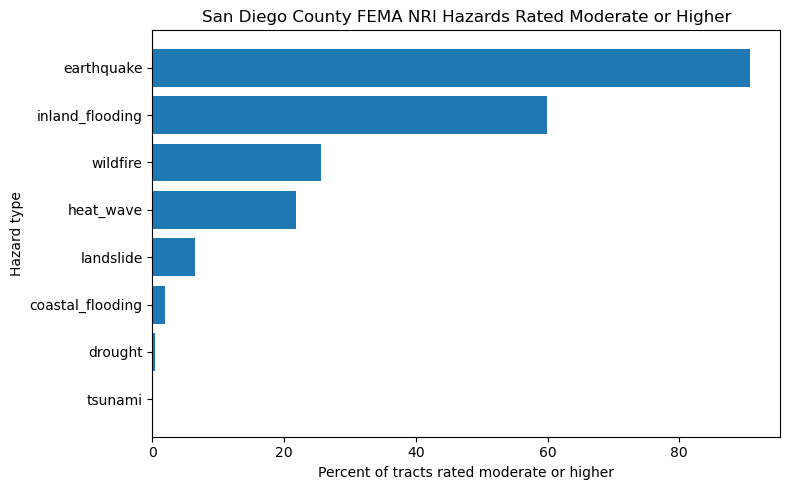

In [81]:
import matplotlib.pyplot as plt

# sorting so the highest risk hazards are easiest to read
hazard_plot = hazard_summary.sort_values(
    'moderate_or_higher_percent',
    ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(hazard_plot['hazard'], hazard_plot['moderate_or_higher_percent'])
plt.xlabel('Percent of tracts rated moderate or higher')
plt.ylabel('Hazard type')
plt.title('San Diego County FEMA NRI Hazards Rated Moderate or Higher')
plt.tight_layout()
plt.show()

In [86]:
# creating summary columns to compare hazard risk across tracts, also looking at percentages so it's easier to compare 
hazard_summary['high_or_very_high'] = (
    hazard_summary['relatively_high'] +
    hazard_summary['very_high'])

hazard_summary['moderate_or_higher'] = (
    hazard_summary['relatively_moderate'] +
    hazard_summary['relatively_high'] +
    hazard_summary['very_high'])
hazard_summary.sort_values('moderate_or_higher_percent', ascending=False)

,hazard,very_high,relatively_high,relatively_moderate,relatively_low,very_low,no_rating,not_applicable,high_or_very_high,moderate_or_higher,high_or_very_high_percent,moderate_or_higher_percent
5,earthquake,16,133,519,68,0,0,0,149,668,20.24,90.76
2,inland_flooding,35,170,236,227,68,0,0,205,441,27.85,59.92
0,wildfire,56,54,78,107,166,275,0,110,188,14.95,25.54
3,heat_wave,0,6,155,487,88,0,0,6,161,0.82,21.88
6,landslide,1,10,37,173,508,7,0,11,48,1.49,6.52
1,coastal_flooding,0,3,11,55,25,642,0,3,14,0.41,1.90
4,drought,0,0,3,29,21,683,0,0,3,0.00,0.41
7,tsunami,0,0,1,22,44,17,652,0,1,0.00,0.14


In [84]:
# saving cleaned tract-level file
data_NRI_sd.to_csv(output_path, index=False)

output_path

WindowsPath('../data/processed/environmental_burden_by_tract.csv')